# Keplerian system from RV
En este notebook se puede poner a prueba la clase ``OrbitalSystem_infe``, la cual permite realizar ajustes de un sistema kepleriano mediante velocidades radiales.
Algunas consideraciones:
- El codigo no se encuentra optimizado para la combinación de velocidades radiales desde distintos instrumentos.
- Actualmente se encuentra en construcción.
- Actualmente se encuentra en una etapa de implementación de derivación de parametros planetarios
- En este notebook no se encuentran los fundamentos teoricos, para referencias, visitar ``La documentación``
### Por: Nikola Salazar Varas, Universidad De Concepción

#### Librerias y configuraciones iniciales


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
import emcee
import corner
import sys
import os
import pandas as pd
from astropy.timeseries import LombScargle
warnings.filterwarnings('ignore')
%matplotlib inline

plt.rcParams.update({
    'font.family'        : 'serif',
    'axes.titlesize'     : 11,
    'axes.labelsize'     : 10,
    'xtick.direction'    : 'in',
    'ytick.direction'    : 'in',
    'xtick.top'          : True,
    'ytick.right'        : True,
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
    'legend.frameon'     : False,
})
print('All imports OK')

All imports OK


### Datos de ejemplo 

In [3]:
# --- HIRES ---: Se colocaron como array para facilidad de lectura del ejemplo, puedes cargar tus propios datos como estimes conveniente.
t_hires_dias = np.array([2458885.00826, 2459077.78600, 2459101.73272, 2459190.16130, 2459215.11314, 2459271.95793, 2459353.81030, 2459378.85255, 2459435.76640, 2459470.73257, 2459566.15808, 2459593.15571, 2459632.97939, 2459662.02642, 2459690.97466, 2459715.96062, 2459739.82355, 2459771.83594, 2459792.76457, 2459826.74058])
rv_hires_ms = np.array([10.14, 0.00, -4.98, -2.09, -2.59, -0.59, -11.43, 10.72, 10.10, 11.16, -12.26, 4.02, 9.78, 4.99, 2.52, -7.21, 4.05, -16.02, -10.21, -8.22])
err_hires_ms = np.array([1.70, 1.80, 1.82, 1.86, 1.88, 1.95, 1.59, 1.72, 1.80, 1.67, 1.95, 1.73, 1.75, 2.23, 1.92, 1.77, 1.76, 1.85, 1.90, 1.71])

# Data from Yana Galarza et al. (2024), AJ, 168, 91
# DOI: 10.3847/1538-3881/ad53bf


## ``OrbytalSystem_infe Class``

In [4]:
ruta_raiz = os.path.abspath('..')


if ruta_raiz not in sys.path:
    sys.path.append(ruta_raiz)

from src.OrbitalModel import OrbitalSystem_infe

## MCMC Settings and run:
En esta sección se debe ajustar el como se correrá la MCMC.

Esta parte cuenta de 6 pasos, porfavor seguirlos en orden:

1. Cargar datos de velocidades radiales
2. Ajustar y ejecutar el ``LombScargle`` para hallar el prior del periodo.
3. Ajustar rangos en el ``log_prior``
4. Ajustar **vector de estimaciones iniciales** ``p0``
5. Iniciar muestreo
6. Extraer las chains





### LombScargle

In [5]:
######### Datos velocidades Radiales #######

data_path = "../data/TOI-1173_MAROON-X.csv"  #Ruta de los datos

df = pd.read_csv(data_path, sep=',')

#----------Hires Data--------
epochs_t_hires =  t_hires_dias #Aquí debe de ir tu tiempo de la velocidades radiales. DEBES DE AJUSTARLO
radial_v_hires = rv_hires_ms #Aquí debe de las velocidades radiales del instrumento.
yerr_rv_hires =  err_hires_ms#Aquí va el error de las RV.

#------Maroon Data----------
epochs_t_maroon = df["time"].values
radial_v_maroon = df["mnvel"].values
yerr_rv_maroon = df["errvel"].values

#------Combinación de datos-----

tel_maroon = df['tel'] #Objetivo usado en datos MaroonX
tel_hires = np.full(len(epochs_t_hires), "HIRES") #Marcador de datos HIRES
tel= np.concatenate([tel_hires, tel_maroon])


epochs_t= np.concatenate([epochs_t_hires, epochs_t_maroon])
radial_v = np.concatenate([radial_v_hires, radial_v_maroon])
yerr_rv = np.concatenate([yerr_rv_hires,yerr_rv_maroon])



idx = np.argsort(epochs_t)
epochs_t = epochs_t[idx]
radial_v = radial_v[idx]
yerr_rv = yerr_rv[idx]
tel = tel[idx]

#--------Mascaras para datos de cada instrumento-----
mask_blue = tel=='MAROON-X Blue'
mask_red = tel== 'MAROON-X Red'
mask_hires = tel=='HIRES'



Periodo = 7.0655 días
Potencia = 0.887


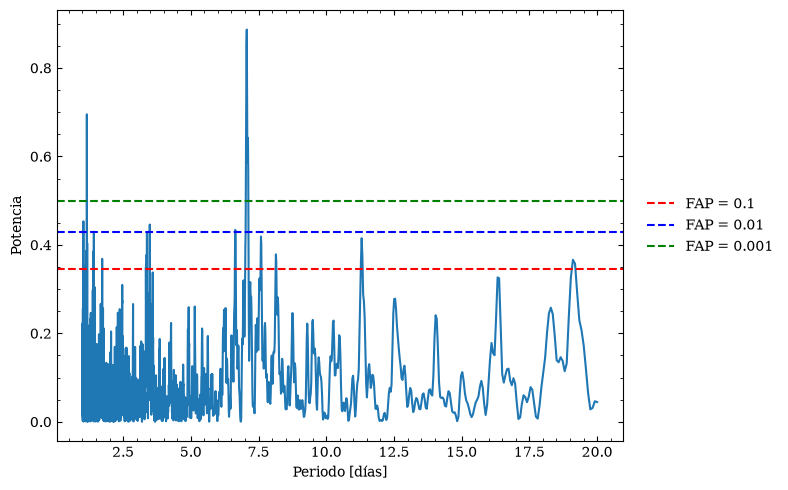

In [6]:


 ########### Analisis de LombScargle ###############


fmin = 1/20 # Frecuencia minima 1/[dias maximos] ESTO LO DEBES DE AJUSTAR
fmax= 1/1 #Frecuencia maxima 1/[días minimos] ESTO LO DEBES DE AJUSTAR

ls = LombScargle(epochs_t, radial_v,yerr_rv)

frec, power = ls.autopower(minimum_frequency=fmin, maximum_frequency=fmax) #Acá se tiene frecuencia y potencia desde el LombScargle

period = 1/frec #Periodo.

best_idx = np.argmax(power) #Se saca el valor maximo de potencia

best_period = period[best_idx] #El mejor periodo basado en la potencia más grande.
best_power = power[best_idx] #La potencia más alta.

print(f"Periodo = {best_period:.4f} días") 
print(f"Potencia = {best_power:.3f}")

################ Grafico de LombScargle con FAP AL 0.1, 0.01, 0.001 ##########

levels = ls.false_alarm_level([0.1, 0.01, 0.001]) #10 %, 1% 0.1%  --- Niveles False Alarm Positive

fig, ax = plt.subplots(figsize=(8,5))
ax.plot(period, power)

ax.axhline(levels[0], ls="--", color="red",label='FAP = 0.1')
ax.axhline(levels[1], ls="--", color="blue",label='FAP = 0.01')
ax.axhline(levels[2], ls="--", color="green",label='FAP = 0.001')
ax.set_xlabel("Periodo [días]")
ax.set_ylabel("Potencia")

plt.legend(loc='center left', bbox_to_anchor=(1.02, 0.5))
plt.tight_layout()
plt.show()


### Likelihood settings

In [7]:
########## Walkers and ndim #########
nwalkers = 32 #Número de caminantes
ndim = 6 #Número de parametros (P, K, e, w, T_0, gamma )

########### Likelihood functions ########## 


def keplerian_log_lh(params,t0, rv_obs, rv_err): 
    P, K, e, w, T_0, gamma = params
    if e<0 or e>=1 or P <= 0 or K<0: #Condiciones fisicas para los parametros
        return -np.inf
    model = OrbitalSystem_infe(e=e, w=w, P=P, K=K, T_0=T_0, gamma=gamma)
    rv_pred = model.RadialVelocity(t0)
    lnl = -0.5 * np.sum((rv_obs - rv_pred)**2 / rv_err**2 + np.log(2 * np.pi * rv_err**2))
    return lnl #Esto es el loglikelihood

def log_prior(params, t0_obs):
    P, K, e, w, T_0, gamma = params
    if (6.0 < P < 8.0 and #TODOS ESTOS RANGOS SE DEBEN AJUSTAR SEGÚN LO QUE SE CONOZCA DEL SISTEMA.
        0.1 < K < 100.0 and
        0.0 <= e < 1.0 and
        0.0 <= w < 2 * np.pi and
        np.min(t0_obs) < T_0 < np.max(t0_obs) and
        -100.0 < gamma < 100.0):
        return 0.0
    return -np.inf

def log_posterior(params, t0, rv_obs, rv_err):
    lp = log_prior(params, t0)
    if not np.isfinite(lp):
        return -np.inf
    return lp + keplerian_log_lh(params, t0, rv_obs, rv_err)

### Priors and posterior


In [17]:
K_prior = 8.0 #Todos estos valores deben ajustar según lo que se conozca del sistema.
e_prior = 0.01
w_prior = 1.3
T_0_prior = epochs_t[0] #Para el valor central se recomienda utilizar como prior el primer epoch que se tenga disponible en los datos.



p0 = np.array([best_period, K_prior, e_prior, w_prior, T_0_prior, 0]) #Nuestras estimaciones iniciales.
pos = p0 + 1e-4 * np.random.randn(nwalkers, ndim) #Esto es ruido adicionado a nuestro vector de estimaciones iniciales.

### Muestreo MCMC

In [18]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_posterior, args=(epochs_t, radial_v,yerr_rv)
)
sampler.run_mcmc(pos, 5000, progress=True);

print("Aceptance fraction:", np.mean(sampler.acceptance_fraction)) #La aceptence Fraction para ver que tan eficientemente los walkers aceptan los p0

100%|██████████| 5000/5000 [00:08<00:00, 555.97it/s]

Aceptance fraction: 0.46066874999999996


### Extracción de las cadenas

In [19]:
######  Flat samples ######

flat_samples = sampler.get_chain(discard=1000, thin=15, flat=True) #Descartamos 1000 primeros pasos, guardamos cada 15 pasos de la cadena (reduciendo la autocorrelación) y aplanamos.
labels =["P", "K", "e", "w", "T_0", "gamma"]


### Calculo de $M_p \sin i$

In [20]:
from src.planet_params import planet_mass, mpsini_posterior

In [21]:
mass_star = 0.911
sigma_star = 0.028

mpsini, mass, sigma_low, sigma_high = mpsini_posterior(flat_samples, Mstar = mass_star, sigma_Mstar= sigma_star, unit= "jup", K_unit="m/s")

---- Units: M_Jup ----


## Resultados MCMC:

En esta sección solo se debe ajustar el nombre del archivo pdf generado por el ``corner plot``.

Considere que los resultados se guardan con $1\sigma $ de incertidumbre, para modificar esto, se debe estudiar si los datos permiten reportar una mejor incertidumbre.


Resultados del ajuste MCMC (Mediana +/- Incertidumbres):
P      = 7.0628 +0.0014 -0.0014
K      = 9.7728 +0.3828 -0.3758
e      = 0.0336 +0.0354 -0.0237
w      = 3.8029 +1.4426 -1.9075
T_0    = 2458889.2808 +1.5961 -2.1566
gamma  = -2.4533 +0.2917 -0.2861
M_p sin(i) = 0.0866 +0.0038 -0.0038 M_Jup

Resultados guardados en 'parametros_mcmc.txt'


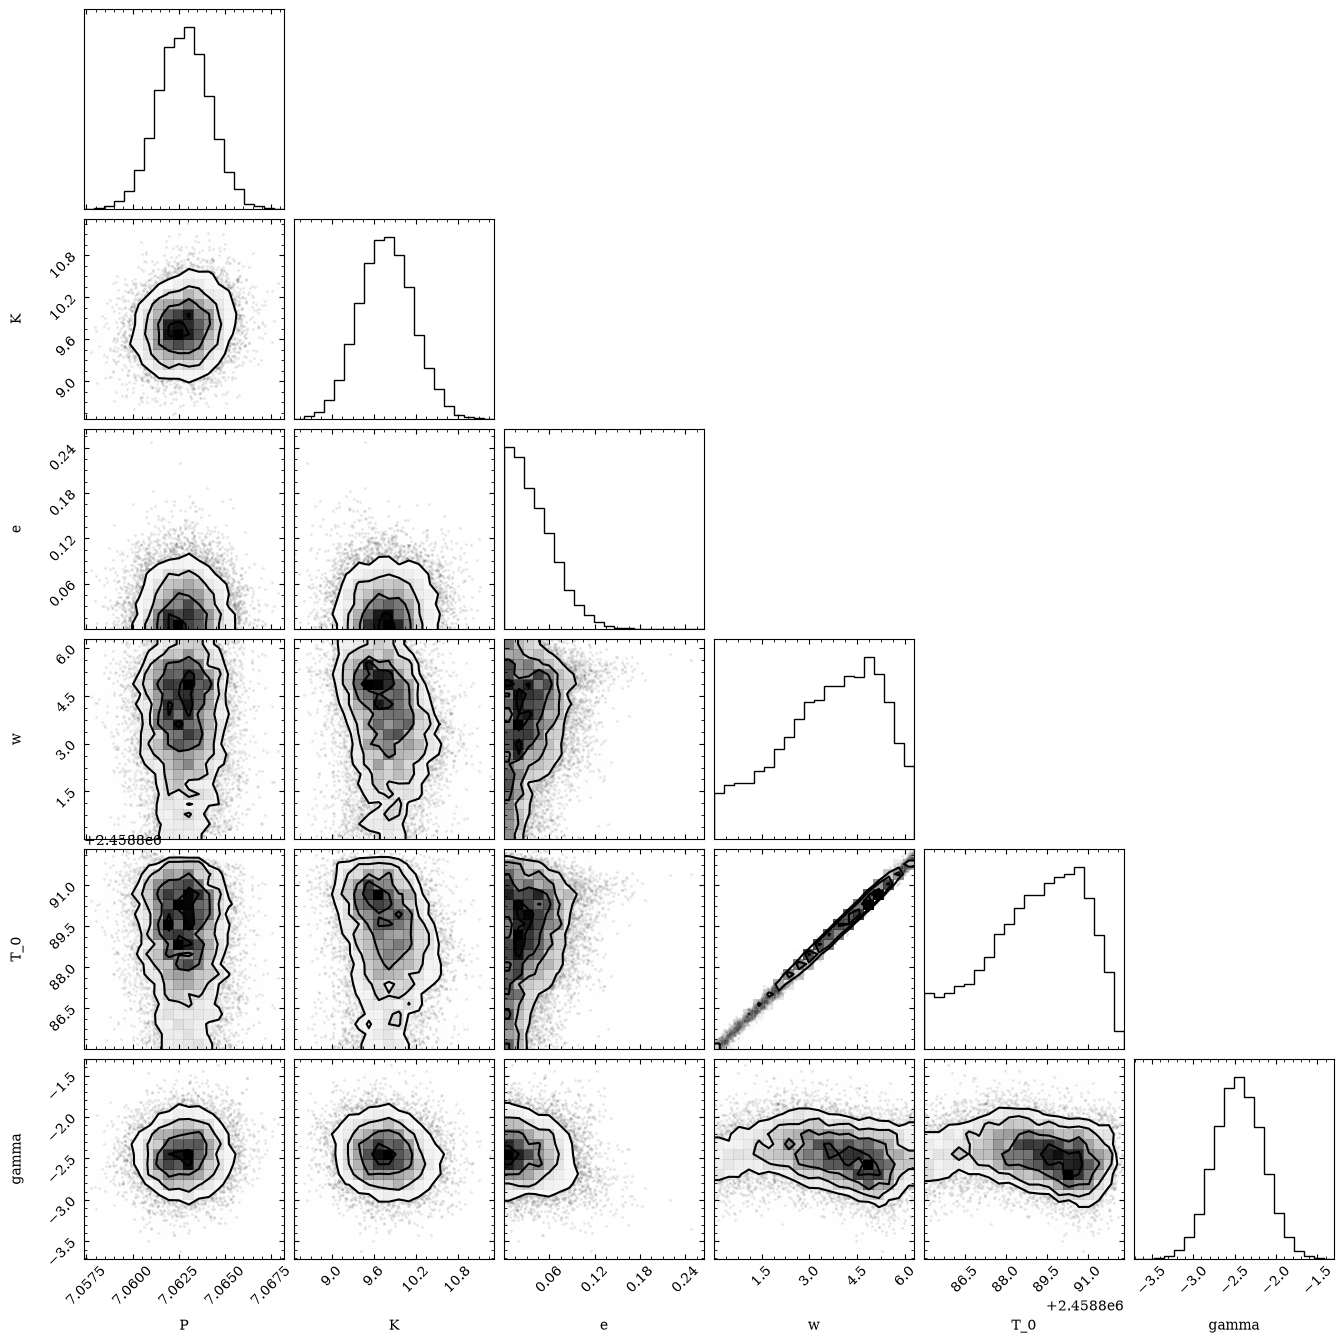

In [22]:
###### Ruta resltados ######
ruta_resultados = "../results"
os.makedirs(ruta_resultados, exist_ok=True)
archivo_salida = os.path.join(ruta_resultados, "parametros_orbitales_mcmc.txt")
corner_salida = os.path.join(ruta_resultados, "corner_plot.pdf")

######## Corner Plot ##########
fig = corner.corner(
    flat_samples,
    labels=labels)
fig.savefig(corner_salida, format="pdf", bbox_inches="tight") #Figura a pdf

######## Visualización y almacenamiento de los resultados ########
resultados_mcmc = {} #Diccionario para los resultados.
print("Resultados del ajuste MCMC (Mediana +/- Incertidumbres):")
for i in range(ndim):
    p16,p50,p84 = np.percentile(flat_samples[:,i], [16, 50, 84]) #Percentiles 16, 50 y 84.
    incertidumbre_inferior = p50 - p16 #1 sigma.
    incertidumbre_superior = p84 - p50
    resultados_mcmc[labels[i]] = {
        "valor_central": p50,
        "error_inferior": incertidumbre_inferior,
        "error_superior": incertidumbre_superior
    }
    print(f"{labels[i]:<6} = {p50:.4f} +{incertidumbre_superior:.4f} -{incertidumbre_inferior:.4f}")
resultados_mcmc["M_p_sin_i_Mjup"] = {
    "valor_central": mass,
    "error_inferior": sigma_low,
    "error_superior": sigma_high
} #Agregamos al diccionario la masa 
print(
    f"{'M_p sin(i)':<6} = "
    f"{mass:.4f} "
    f"+{sigma_high:.4f} "
    f"-{sigma_low:.4f} M_Jup"
)

with open(archivo_salida, "w") as f:
    f.write("Parametro,Valor_Central,Error_Superior,Error_Inferior\n")
    for param, datos in resultados_mcmc.items():
        f.write(f"{param},{datos['valor_central']:.6f},{datos['error_superior']:.6f},{datos['error_inferior']:.6f}\n")

print("\nResultados guardados en 'parametros_mcmc.txt'")


## Curva de velocidad radial
En esta sección se constuye la curva de velocidad radial a partir de los datos de ejemplo.

Para construir tu propia curva de velocidad radial, debes de seguir los siguientes pasos:

1. Determinar si es necesario aplicar un ``cambio de unidades conveniente``, en caso de que no, debes de eliminar esa parte y ajustar nombre de variables.
2. Crear el sistema orbital a partir de los valores del MCMC
3. Ajustar el phase folding.
4. Cambiar titulo del plot
5. Ejecutar celda del plot.

In [14]:
###### Resultados desde el diccionario ######
p_mcmc = resultados_mcmc["P"]["valor_central"]
k_mcmc = resultados_mcmc["K"]["valor_central"]
e_mcmc = resultados_mcmc["e"]["valor_central"]
w_mcmc = resultados_mcmc["w"]["valor_central"]
t0_mcmc = resultados_mcmc["T_0"]["valor_central"]
gamma_mcmc = resultados_mcmc["gamma"]["valor_central"]

####### Cambio de unidades convenientes #####

k_mcmc_km = k_mcmc/1000 # m--->km
t0_seg_mc = t0_mcmc*24*3600 # day---->seg
period_seg = p_mcmc* 24*3600 # day---->seg
gamma_seg = gamma_mcmc/1000 # m/s--->km/s
t_seg = epochs_t*24*3600 # day---->seg
rv_km = radial_v/1000 # m/s--->km/s
yerr_rv_km = yerr_rv/1000 # m/s--->km/s


######## Creación del sistema con los valores del MCMC #######
mejor_sistema_seg = OrbitalSystem_infe(e=e_mcmc, w=w_mcmc, P=period_seg, K=k_mcmc_km, T_0=t0_seg_mc, gamma=gamma_seg)

######## Ajuste del phase folding #####

desfase = 0.385 #Desfase para centrar la curva de rv DEBE AJUSTARSE
t_fase = np.linspace(t0_seg_mc, period_seg+t0_seg_mc,1000) #Creamos el tiempo de modelo desde el tiempo central hasta el periodo + tiempo central
fase_model_raw = mejor_sistema_seg.OrbitalPhase(t_fase) #Se crea la fase del modelo
fase_model = np.where(fase_model_raw >desfase, fase_model_raw-1, fase_model_raw) #se aplica el desfase

f_data_raw_mc =mejor_sistema_seg.OrbitalPhase(t_seg) #se calcula la orbital phase desde las rv's

model_rv = mejor_sistema_seg.RadialVelocity(t_fase) #se genera el modelo de rv para el tiempo total de la fase

fase_data_mc = np.where(f_data_raw_mc>desfase, f_data_raw_mc-1, f_data_raw_mc) #se aplica el mismo defase a la phase orbital de los datos.
#####Indices ordenados####
indices_ordenados = np.argsort(fase_model)
fases_modelo_ord = fase_model[indices_ordenados]
rv_modelo_ord = model_rv[indices_ordenados]


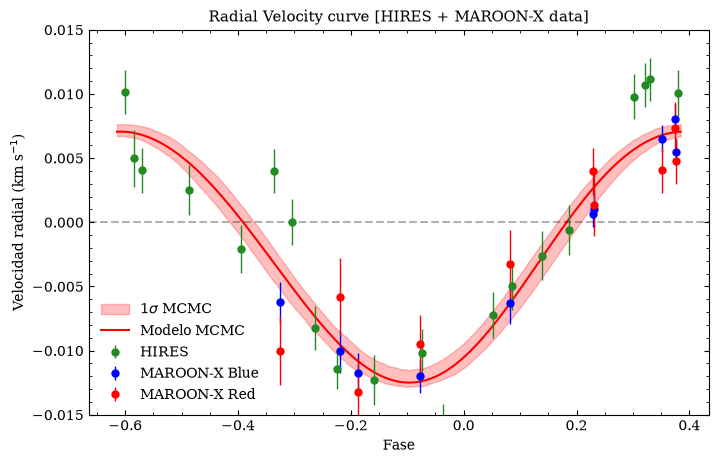

In [15]:
############# Plot curva de velocidad radial #########



#------------------------- Muestreo inspirado en codigo Profesor Jhon Yana Galarza--------
# Muestreo de la banda 1-sigma usando los mismos índices
num_muestras = 200
indices_aleatorios = np.random.choice(len(flat_samples), size=num_muestras, replace=False)

rv_matriz_modelos = []
for idx in indices_aleatorios:
    p_i, k_i, e_i, w_i, t0_i, gamma_i = flat_samples[idx]
    
    sistema_temp = OrbitalSystem_infe(
        e=e_i,
        w=w_i,
        P=p_i * 24.0 * 3600.0,
        K=k_i / 1000.0,
        T_0=t0_i * 24.0 * 3600.0,
        gamma=gamma_i / 1000.0
    )
    rv_matriz_modelos.append(sistema_temp.RadialVelocity(t_fase))

cota_inf_raw, cota_sup_raw = np.percentile(rv_matriz_modelos, [16, 84], axis=0)

# Reordenamiento de las cotas con los mismos índices
cota_inf_ord = cota_inf_raw[indices_ordenados]
cota_sup_ord = cota_sup_raw[indices_ordenados]
#-----------------------------------------------------------


curve_rv_out = os.path.join(ruta_resultados, "RVcurve.pdf")


plt.figure(figsize=(8, 5))
plt.fill_between(fases_modelo_ord, cota_inf_ord, cota_sup_ord, color="red", alpha=0.25, label=r"$1\sigma$ MCMC") #Rellenado a 1sigma
plt.plot(fases_modelo_ord, rv_modelo_ord, color="red", label="Modelo MCMC")

#-----------Datos con barras de error--------
plt.errorbar(fase_data_mc[mask_hires], rv_km[mask_hires], yerr=yerr_rv_km[mask_hires], fmt='o', color='forestgreen', mec='forestgreen', ecolor='forestgreen', ms=5, elinewidth=1, label='HIRES')
plt.errorbar(fase_data_mc[mask_blue], rv_km[mask_blue], yerr=yerr_rv_km[mask_blue], fmt='o', color='blue', mec='blue', ecolor='blue', ms=5, elinewidth=1, label='MAROON-X Blue')
plt.errorbar(fase_data_mc[mask_red], rv_km[mask_red], yerr=yerr_rv_km[mask_red], fmt='o', color='red', mec='red', ecolor='red', ms=5, elinewidth=1, label='MAROON-X Red')

plt.axhline(0, color='black', linestyle='--', alpha=0.3)
plt.ylim(-0.015, 0.015)
plt.xlabel("Fase")
plt.ylabel(r"Velocidad radial (km s$^{-1}$)")
plt.title("Radial Velocity curve [HIRES + MAROON-X data]")
plt.legend()
plt.savefig(curve_rv_out, format="pdf", bbox_inches="tight" )
plt.show()

### Ejemplo de plot sin desfase:
En este plot se puede ver porque se decidió usar como desfase el valor ``0.27`` para visualizar la curva de velocidad radial de manera similar a la del paper de TOI1173. Esto más que una decisión estetica, te permite visualizar como debería de verse realmente un ciclo completo de esta curva.

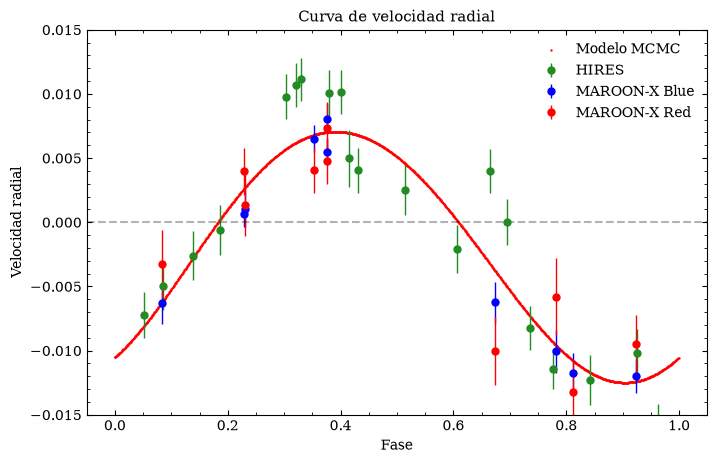

In [16]:
plt.figure(figsize=(8,5))
plt.scatter(fase_model_raw, model_rv, color="red", label="Modelo MCMC", s= 0.5)


plt.errorbar(f_data_raw_mc[mask_hires], rv_km[mask_hires], yerr=yerr_rv_km[mask_hires], fmt='o', color='forestgreen', mec='forestgreen', ecolor='forestgreen', ms=5, elinewidth=1, label='HIRES')
plt.errorbar(f_data_raw_mc[mask_blue], rv_km[mask_blue], yerr=yerr_rv_km[mask_blue], fmt='o', color='blue', mec='blue', ecolor='blue', ms=5, elinewidth=1, label='MAROON-X Blue')
plt.errorbar(f_data_raw_mc[mask_red], rv_km[mask_red], yerr=yerr_rv_km[mask_red], fmt='o', color='red', mec='red', ecolor='red', ms=5, elinewidth=1, label='MAROON-X Red')


plt.axhline(0, color='black', linestyle='--', alpha=0.3) 
#plt.xlim(0,0.8)
plt.ylim(-0.015,0.015 )
plt.xlabel("Fase")
plt.ylabel("Velocidad radial")
plt.title("Curva de velocidad radial")
plt.legend()
plt.show()